# Part 2: Univariate analysis
- **Owner:** Ngoc
- **Data:** `data/listings_clean.csv` from `01_cleaning.ipynb` (92,635 listings, 69 columns).
- **Goal:** describe each variable on its own (shape, center, spread, skew, outliers) before the bivariate and multivariate parts relate them to `top_rated`.
- **Samples:** general variables use all listings. Anything about the rating uses rated listings only (70,708).
- **Not used:** host response rate, acceptance rate and response time are empty in this snapshot. Review sub-scores and `host_is_superhost` are leakage for the model, so they are only described here, never used as features.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

BLUE, GREY, RED = "#2471A3", "#95A5A6", "#C0392B"

df = pd.read_csv("../data/listings_clean.csv", low_memory=False)
rated = df[df["top_rated"].notna()]
print(df.shape, "rated:", len(rated))


def clean_axes(ax):
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)


def bucket_counts(s, cap, fmt="{:g}"):
    # Share (%) of each value, with everything at or above `cap` grouped as "cap+"
    s = s.dropna()
    lab = s.where(s < cap, cap).map(lambda v: fmt.format(v) + ("+" if v >= cap else ""))
    order = sorted(lab.unique(), key=lambda x: float(x.rstrip("+")))
    return (lab.value_counts(normalize=True) * 100).reindex(order)


def bar_pct(ax, share, color=BLUE, horizontal=False):
    bars = (ax.barh if horizontal else ax.bar)(share.index.astype(str), share.values, color=color)
    ax.bar_label(bars, labels=[f"{v:.0f}%" if v >= 1 else "<1%" for v in share.values],
                 padding=2, fontsize=7)
    clean_axes(ax)
    return bars

(92635, 69) rated: 70708


## Step 1: Summary statistics
Center, spread and skew of the main numeric variables. A skew above 1 means a long right tail, which these variables need log scales or grouping for in charts.

In [2]:
num_cols = ["review_scores_rating", "price_capped", "accommodates", "bedrooms", "beds", "bathrooms",
            "minimum_nights", "availability_365", "number_of_reviews", "reviews_per_month",
            "estimated_occupancy_l365d", "calculated_host_listings_count", "hosts_time_as_host_years"]
summary = df[num_cols].describe().T
summary["missing_pct"] = (df[num_cols].isna().mean() * 100).round(1)
summary["skew"] = df[num_cols].skew()
summary.round(2)

,count,mean,std,min,25%,50%,75%,max,missing_pct,skew
review_scores_rating,70708.0,4.69,0.48,1.00,4.60,4.83,5.00,5.00,23.7,-3.94
price_capped,62238.0,244.37,225.07,2.23,100.00,180.00,300.10,1373.46,32.8,2.54
accommodates,92635.0,3.39,2.12,1.00,2.00,3.00,4.00,16.00,0.0,1.62
bedrooms,68653.0,1.77,1.04,0.00,1.00,1.00,2.00,30.00,25.9,2.92
beds,60161.0,2.02,1.45,1.00,1.00,2.00,3.00,50.00,35.1,3.38
bathrooms,92509.0,1.33,0.69,0.00,1.00,1.00,1.50,30.00,0.1,4.79
minimum_nights,92630.0,4.56,20.90,1.00,1.00,2.00,3.00,1125.00,0.0,26.13
availability_365,92635.0,152.66,141.13,0.00,0.00,127.00,301.00,365.00,0.0,0.25
number_of_reviews,92635.0,24.15,55.08,0.00,1.00,5.00,23.00,1959.00,0.0,6.52
reviews_per_month,70711.0,0.99,1.32,0.01,0.14,0.49,1.28,32.17,23.7,3.13


## Figure 5: The target, overall rating
Shows how ratings are spread and how the 4.8 cut point splits rated listings into the two classes.

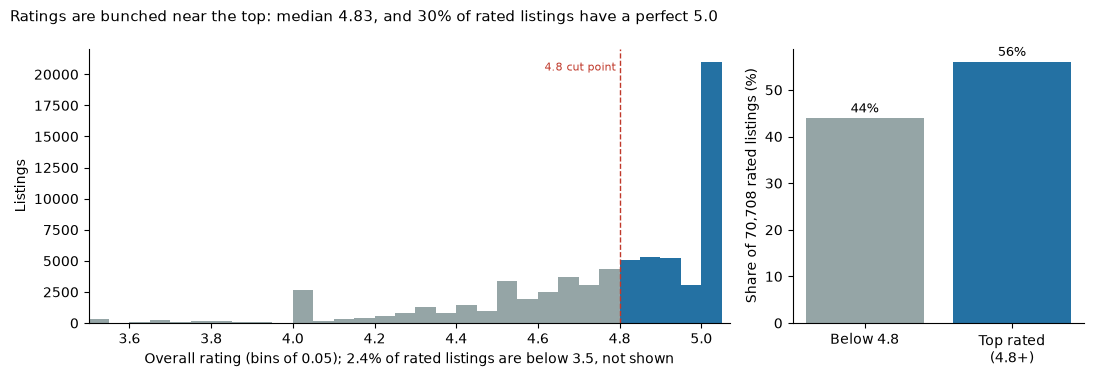

**Insight:** the rating is strongly left-skewed (skew -3.9); the middle half of rated listings lies between 4.60 and 5.00, and only 4% score below 4.0. The 4.8 cut point gives fairly balanced classes (56% vs 44%), so the model does not need resampling, but the classes are separated by small rating differences.

In [3]:
rt = rated["review_scores_rating"]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [2.2, 1]})

ax = axes[0]
edges = np.linspace(1, 5.05, 82)  # 0.05-wide bins, last bin holds exactly 5.0
_, _, patches = ax.hist(rt, bins=edges, color=GREY)
for p in patches:
    if p.get_x() >= 4.8 - 1e-9:
        p.set_facecolor(BLUE)
ax.axvline(4.8, color=RED, ls="--", lw=1)
ax.text(4.79, ax.get_ylim()[1] * 0.92, "4.8 cut point", ha="right", fontsize=8, color=RED)
ax.set_xlim(3.5, 5.07)
ax.set_xlabel(f"Overall rating (bins of 0.05); {(rt < 3.5).mean() * 100:.1f}% of rated listings are below 3.5, not shown")
ax.set_ylabel("Listings")
clean_axes(ax)

ax = axes[1]
target_share = rated["top_rated"].map({1: "Top rated\n(4.8+)", 0: "Below 4.8"}).value_counts(normalize=True) * 100
target_share = target_share.reindex(["Below 4.8", "Top rated\n(4.8+)"])
bars = ax.bar(target_share.index, target_share.values, color=[GREY, BLUE])
ax.bar_label(bars, labels=[f"{v:.0f}%" for v in target_share.values], padding=2, fontsize=9)
ax.set_ylabel(f"Share of {len(rated):,} rated listings (%)")
clean_axes(ax)

fig.suptitle(f"Ratings are bunched near the top: median {rt.median():.2f}, and {(rt == 5).mean() * 100:.0f}% "
             f"of rated listings have a perfect 5.0", x=0.01, ha="left", fontsize=11)
plt.tight_layout()
plt.savefig("../figures/fig5_rating_distribution.png", dpi=500, bbox_inches="tight")
plt.show()

display(Markdown(
    f"**Insight:** the rating is strongly left-skewed (skew {rt.skew():.1f}); the middle half of rated listings lies between "
    f"{rt.quantile(0.25):.2f} and {rt.quantile(0.75):.2f}, and only {(rt < 4).mean() * 100:.0f}% score below 4.0. The 4.8 cut point gives fairly balanced classes "
    f"({target_share.iloc[1]:.0f}% vs {target_share.iloc[0]:.0f}%), so the model does not need resampling, but the classes are "
    f"separated by small rating differences."))

## Figure 6: Nightly price
Uses `price_capped` (top 1% capped in cleaning). Price is missing for 32.8% of listings, which are mostly listings that cannot be booked.

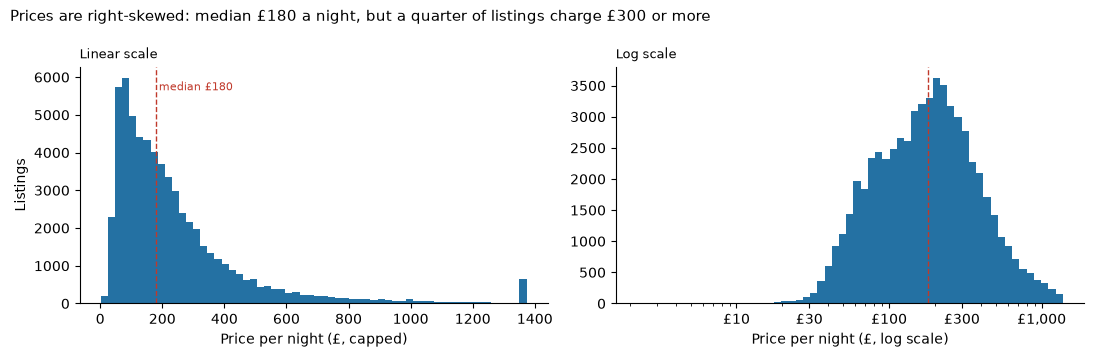

**Insight:** based on 62,238 priced listings, price has skew 2.5 even after capping, while on a log scale it is close to bell-shaped. Later parts should use log price (or price bands) rather than raw price.

In [4]:
p = df["price_capped"].dropna()
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

ax = axes[0]
ax.hist(p, bins=60, color=BLUE)
ax.set_xlabel("Price per night (£, capped)")
ax.set_ylabel("Listings")
ax.set_title("Linear scale", loc="left", fontsize=9)

ax = axes[1]
ax.hist(p, bins=np.logspace(np.log10(p.min()), np.log10(p.max()), 60), color=BLUE)
ax.set_xscale("log")
ax.set_xticks([10, 30, 100, 300, 1000])
ax.set_xticklabels(["£10", "£30", "£100", "£300", "£1,000"])
ax.set_xlabel("Price per night (£, log scale)")
ax.set_title("Log scale", loc="left", fontsize=9)

for ax in axes:
    ax.axvline(p.median(), color=RED, ls="--", lw=1)
    clean_axes(ax)
axes[0].text(p.median() * 1.05, axes[0].get_ylim()[1] * 0.9, f"median £{p.median():.0f}", fontsize=8, color=RED)

fig.suptitle(f"Prices are right-skewed: median £{p.median():.0f} a night, but a quarter of listings charge "
             f"£{p.quantile(0.75):.0f} or more", x=0.01, ha="left", fontsize=11)
plt.tight_layout()
plt.savefig("../figures/fig6_price_distribution.png", dpi=500, bbox_inches="tight")
plt.show()

display(Markdown(
    f"**Insight:** based on {len(p):,} priced listings, price has skew {p.skew():.1f} even after capping, while on a "
    f"log scale it is close to bell-shaped. Later parts should use log price (or price bands) "
    f"rather than raw price."))

## Figure 7: Room type and property type
Shows what kind of space is being rented.

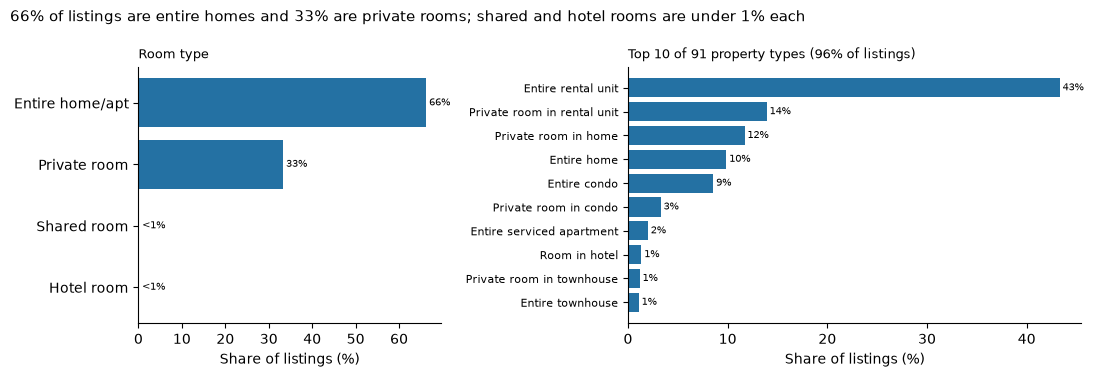

**Insight:** room type is dominated by two categories, so shared and hotel rooms (383 listings) are too small to compare reliably. `property_type` has a long tail of rare labels; grouping it into a few categories is better for modeling.

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1, 1.5]})
room = (df["room_type"].value_counts(normalize=True) * 100).sort_values()
bar_pct(axes[0], room, horizontal=True)
axes[0].set_xlabel("Share of listings (%)")
axes[0].set_title("Room type", loc="left", fontsize=9)

prop = (df["property_type"].value_counts(normalize=True) * 100)
top10 = prop.head(10).sort_values()
bar_pct(axes[1], top10, horizontal=True)
axes[1].set_xlabel("Share of listings (%)")
axes[1].set_title(f"Top 10 of {df['property_type'].nunique()} property types "
                  f"({top10.sum():.0f}% of listings)", loc="left", fontsize=9)
axes[1].tick_params(axis="y", labelsize=8)

fig.suptitle(f"{room['Entire home/apt']:.0f}% of listings are entire homes and {room['Private room']:.0f}% are "
             f"private rooms; shared and hotel rooms are under 1% each", x=0.01, ha="left", fontsize=11)
plt.tight_layout()
plt.savefig("../figures/fig7_room_property_type.png", dpi=500, bbox_inches="tight")
plt.show()

display(Markdown(
    f"**Insight:** room type is dominated by two categories, so shared and hotel rooms "
    f"({(df['room_type'].isin(['Shared room', 'Hotel room'])).sum():,} listings) are too small to compare reliably. "
    f"`property_type` has a long tail of rare labels; grouping it into a few categories is better for modeling."))

## Figure 8: Listing size
Guest capacity, bedrooms, beds and bathrooms. Large values are grouped into a final "N+" bar.

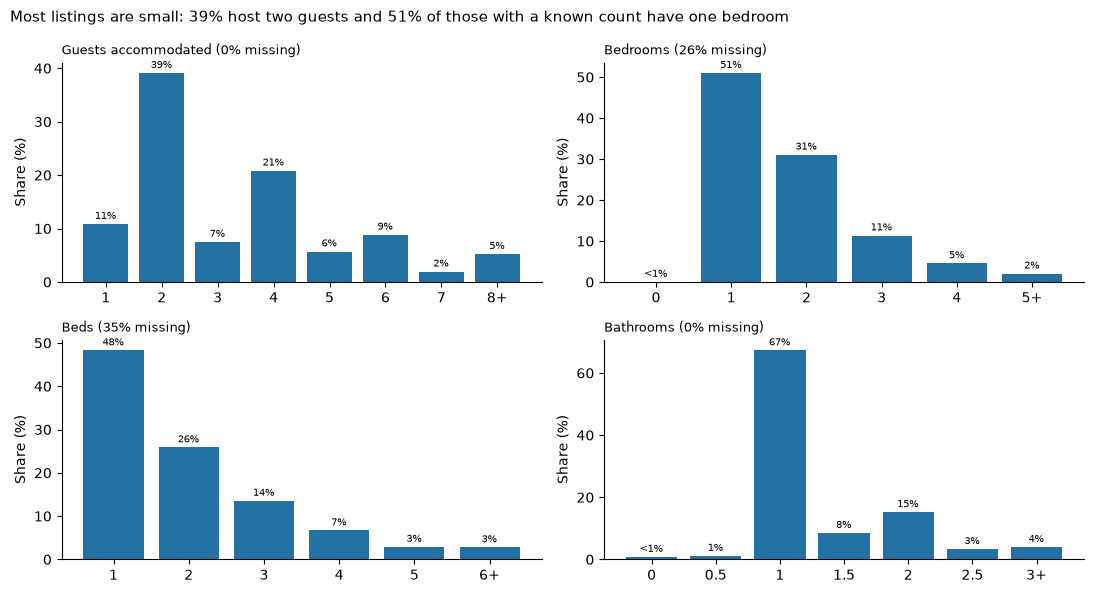

**Insight:** all four size variables are right-skewed, with a few large homes (up to 30 bedrooms and 50 beds). Guest capacity is even numbers for most listings (2, 4, 6). `bedrooms` and `beds` are missing for a quarter to a third of listings, so `accommodates` (complete) is the most reliable size measure.

In [6]:
size_specs = [("accommodates", 8, "Guests accommodated"), ("bedrooms", 5, "Bedrooms"),
              ("beds", 6, "Beds"), ("bathrooms", 3, "Bathrooms")]
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for ax, (col, cap, label) in zip(axes.ravel(), size_specs):
    bar_pct(ax, bucket_counts(df[col], cap))
    ax.set_title(f"{label} ({df[col].isna().mean() * 100:.0f}% missing)", loc="left", fontsize=9)
    ax.set_ylabel("Share (%)")

acc = df["accommodates"].value_counts(normalize=True) * 100
bed1 = (df["bedrooms"].dropna() == 1).mean() * 100
fig.suptitle(f"Most listings are small: {acc[2]:.0f}% host two guests and {bed1:.0f}% of those with a "
             f"known count have one bedroom", x=0.01, ha="left", fontsize=11)
plt.tight_layout()
plt.savefig("../figures/fig8_listing_size.png", dpi=500, bbox_inches="tight")
plt.show()

display(Markdown(
    f"**Insight:** all four size variables are right-skewed, with a few large homes (up to "
    f"{df['bedrooms'].max():.0f} bedrooms and {df['beds'].max():.0f} beds). Guest capacity is even numbers "
    f"for most listings (2, 4, 6). `bedrooms` and `beds` are missing for a quarter to a third of listings, "
    f"so `accommodates` (complete) is the most reliable size measure."))

## Figure 9: Listings by borough
Count of listings in each of London's 33 boroughs (`neighbourhood_cleansed`).

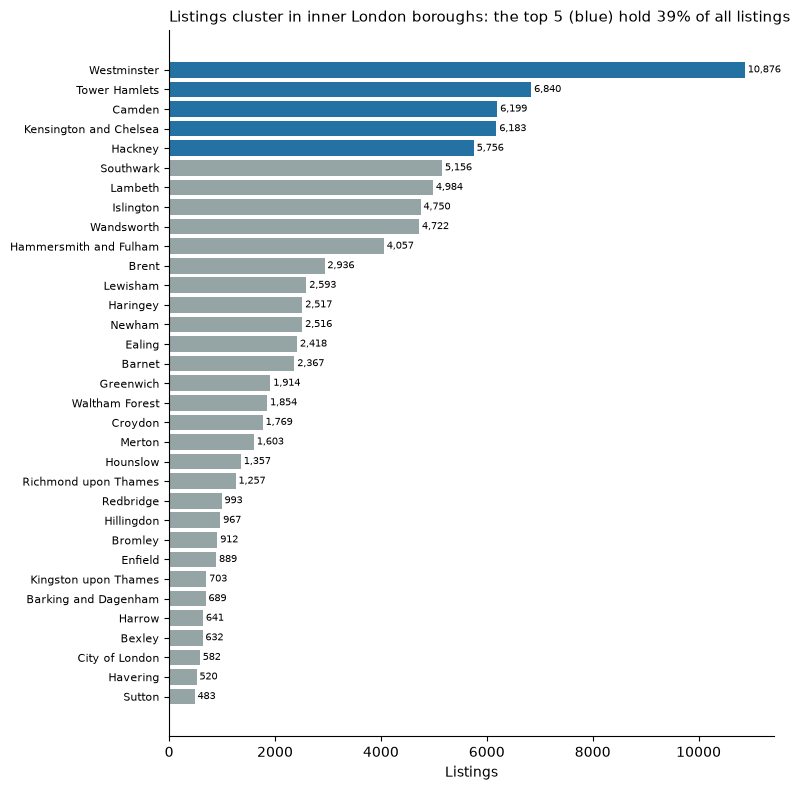

**Insight:** Westminster alone has 10,876 listings, about 23 times as many as Sutton (483). Borough samples are very uneven, so outer-borough comparisons in later parts rest on small groups.

In [7]:
nb = df["neighbourhood_cleansed"].value_counts().sort_values()
top5_share = nb.tail(5).sum() / nb.sum() * 100
fig, ax = plt.subplots(figsize=(8, 8))
bars = ax.barh(nb.index, nb.values, color=[BLUE if i >= len(nb) - 5 else GREY for i in range(len(nb))])
ax.bar_label(bars, labels=[f"{v:,}" for v in nb.values], padding=2, fontsize=7)
ax.set_xlabel("Listings")
ax.tick_params(axis="y", labelsize=8)
clean_axes(ax)
ax.set_title(f"Listings cluster in inner London boroughs: the top 5 (blue) hold {top5_share:.0f}% of all listings",
             loc="left", fontsize=11)
plt.tight_layout()
plt.savefig("../figures/fig9_listings_by_borough.png", dpi=500, bbox_inches="tight")
plt.show()

display(Markdown(
    f"**Insight:** {nb.index[-1]} alone has {nb.iloc[-1]:,} listings, about {nb.iloc[-1] / nb.iloc[0]:.0f} times "
    f"as many as {nb.index[0]} ({nb.iloc[0]:,}). Borough samples are very uneven, so outer-borough "
    f"comparisons in later parts rest on small groups."))

## Figure 10: Booking rules and activity
Minimum stay, availability in the next 365 days, and total number of reviews.

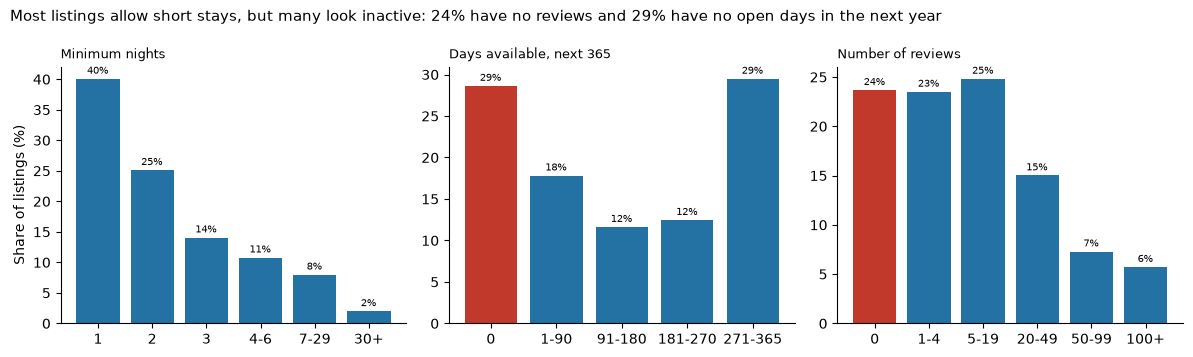

**Insight:** 79% of listings accept stays of 3 nights or fewer. Reviews are extremely skewed (median 5, max 1,959, skew 7), so review counts need a log scale. Listings with 0 available days are either fully booked or blocked by the host; the data cannot tell these apart.

In [8]:
def labelled_bins(s, bins, labels):
    return (pd.cut(s, bins=bins, labels=labels, right=True).value_counts(normalize=True) * 100).reindex(labels)

min_n = labelled_bins(df["minimum_nights"], [0, 1, 2, 3, 6, 29, np.inf], ["1", "2", "3", "4-6", "7-29", "30+"])
avail = labelled_bins(df["availability_365"], [-1, 0, 90, 180, 270, 365], ["0", "1-90", "91-180", "181-270", "271-365"])
revs = labelled_bins(df["number_of_reviews"], [-1, 0, 4, 19, 49, 99, np.inf], ["0", "1-4", "5-19", "20-49", "50-99", "100+"])

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, share, title in zip(axes, [min_n, avail, revs],
                            ["Minimum nights", "Days available, next 365", "Number of reviews"]):
    bar_pct(ax, share, color=[RED if share.index[0] == lab and title != "Minimum nights" else BLUE
                              for lab in share.index])
    ax.set_title(title, loc="left", fontsize=9)
axes[0].set_ylabel("Share of listings (%)")

fig.suptitle(f"Most listings allow short stays, but many look inactive: {revs['0']:.0f}% have no reviews and "
             f"{avail['0']:.0f}% have no open days in the next year", x=0.01, ha="left", fontsize=11)
plt.tight_layout()
plt.savefig("../figures/fig10_booking_activity.png", dpi=500, bbox_inches="tight")
plt.show()

nr = df["number_of_reviews"]
display(Markdown(
    f"**Insight:** {(df['minimum_nights'] <= 3).mean() * 100:.0f}% of listings accept stays of 3 nights or fewer. "
    f"Reviews are extremely skewed (median {nr.median():.0f}, max {nr.max():,}, skew {nr.skew():.0f}), so review "
    f"counts need a log scale. Listings with 0 available days are either fully booked or blocked by the host; "
    f"the data cannot tell these apart."))

## Figure 11: Hosts
How many listings each host runs, how long they have hosted, and profile flags. Superhost is shown for context only; it is excluded from the model because it depends on the rating.

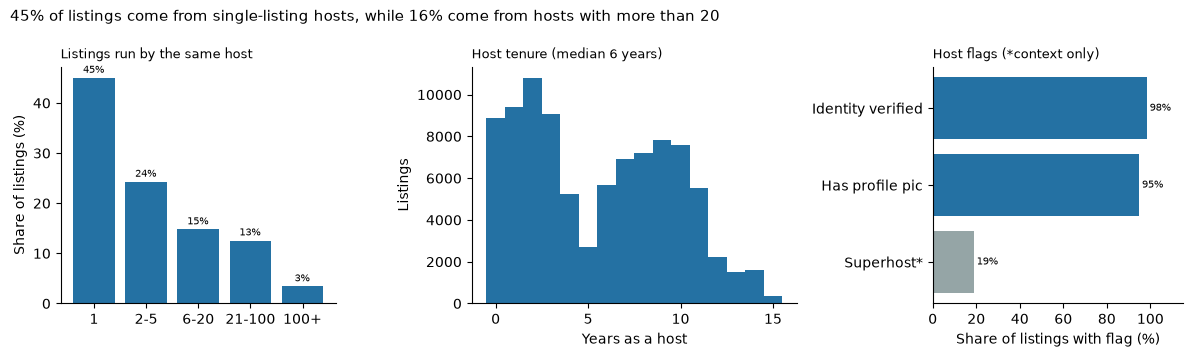

**Insight:** London has many professional multi-listing hosts (the largest runs 501 listings), so host type is worth testing in the bivariate part. Tenure has two peaks (about 2 and 9 years), suggesting a newer wave of hosts alongside long-standing ones. Identity verification (98%) and profile pictures (95%) are near-universal, so they carry little information for the model.

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), gridspec_kw={"width_ratios": [1.1, 1.3, 1]})

hl = labelled_bins(df["calculated_host_listings_count"], [0, 1, 5, 20, 100, np.inf],
                   ["1", "2-5", "6-20", "21-100", "100+"])
bar_pct(axes[0], hl)
axes[0].set_title("Listings run by the same host", loc="left", fontsize=9)
axes[0].set_ylabel("Share of listings (%)")

ten = df["hosts_time_as_host_years"].dropna()
axes[1].hist(ten, bins=np.arange(-0.5, ten.max() + 1.5, 1), color=BLUE)
axes[1].set_xlabel("Years as a host")
axes[1].set_ylabel("Listings")
axes[1].set_title(f"Host tenure (median {ten.median():.0f} years)", loc="left", fontsize=9)
clean_axes(axes[1])

flags = pd.Series({c: (df[c] == "t").mean() * 100 for c in
                   ["host_identity_verified", "host_has_profile_pic", "host_is_superhost"]})
flags.index = ["Identity verified", "Has profile pic", "Superhost*"]
bar_pct(axes[2], flags.sort_values(), color=[GREY, BLUE, BLUE], horizontal=True)
axes[2].set_xlim(0, 115)
axes[2].set_xlabel("Share of listings with flag (%)")
axes[2].set_title("Host flags (*context only)", loc="left", fontsize=9)

fig.suptitle(f"{hl['1']:.0f}% of listings come from single-listing hosts, while "
             f"{hl['21-100'] + hl['100+']:.0f}% come from hosts with more than 20", x=0.01, ha="left", fontsize=11)
plt.tight_layout()
plt.savefig("../figures/fig11_hosts.png", dpi=500, bbox_inches="tight")
plt.show()

display(Markdown(
    f"**Insight:** London has many professional multi-listing hosts (the largest runs "
    f"{df['calculated_host_listings_count'].max()} listings), so host type is worth testing in the bivariate part. "
    f"Tenure has two peaks (about 2 and 9 years), suggesting a newer wave of hosts alongside long-standing ones. "
    f"Identity verification ({flags['Identity verified']:.0f}%) and profile pictures ({flags['Has profile pic']:.0f}%) "
    f"are near-universal, so they carry little information for the model."))

## Figure 12: Amenities
Number of amenities listed per listing, and the most common amenities. `amenities` is stored as a JSON list in text.

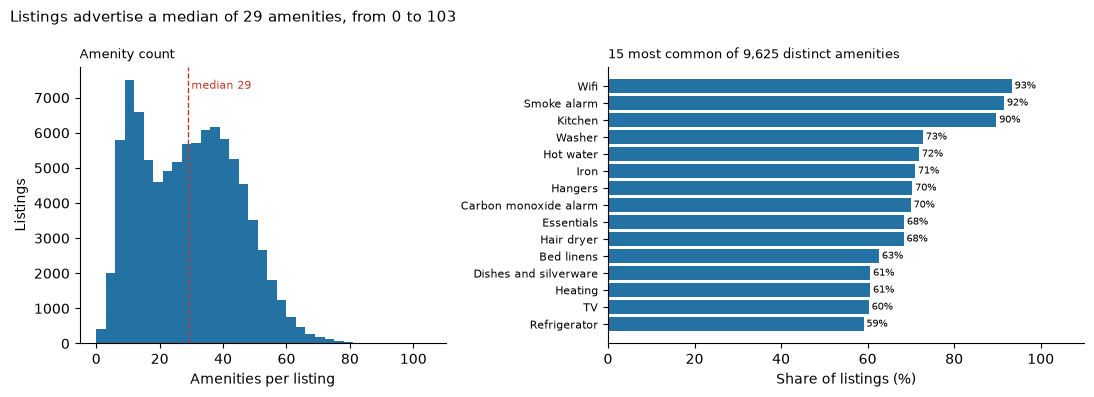

**Insight:** the count has two peaks (around 10 and around 40), and only 192 listings list none. The 9,625 distinct names include many free-text variants (brand names, sizes), so rarer amenities need grouping before use. Basics such as wifi appear on most listings, so they cannot separate top-rated listings. The amenity count, and rarer amenities, are better candidates for the next parts.

In [10]:
amen = df["amenities"].apply(lambda s: json.loads(s) if isinstance(s, str) else [])
n_amen = amen.str.len()
common = (amen.explode().value_counts() / len(df) * 100).head(15).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [1, 1.3]})
axes[0].hist(n_amen, bins=np.arange(0, n_amen.max() + 3, 3), color=BLUE)
axes[0].axvline(n_amen.median(), color=RED, ls="--", lw=1)
axes[0].text(n_amen.median() + 1, axes[0].get_ylim()[1] * 0.92, f"median {n_amen.median():.0f}", fontsize=8, color=RED)
axes[0].set_xlabel("Amenities per listing")
axes[0].set_ylabel("Listings")
axes[0].set_title("Amenity count", loc="left", fontsize=9)
clean_axes(axes[0])

bar_pct(axes[1], common, horizontal=True)
axes[1].set_xlim(0, 110)
axes[1].set_xlabel("Share of listings (%)")
axes[1].set_title(f"15 most common of {amen.explode().nunique():,} distinct amenities", loc="left", fontsize=9)
axes[1].tick_params(axis="y", labelsize=8)

fig.suptitle(f"Listings advertise a median of {n_amen.median():.0f} amenities, from {n_amen.min()} to {n_amen.max()}",
             x=0.01, ha="left", fontsize=11)
plt.tight_layout()
plt.savefig("../figures/fig12_amenities.png", dpi=500, bbox_inches="tight")
plt.show()

display(Markdown(
    f"**Insight:** the count has two peaks (around 10 and around 40), and only {(n_amen == 0).sum():,} listings list none. "
    f"The {amen.explode().nunique():,} distinct names include many free-text variants (brand names, sizes), so "
    f"rarer amenities need grouping before use. Basics such as "
    f"{common.index[-1].lower()} appear on most listings, so they cannot separate top-rated listings. "
    f"The amenity count, and rarer amenities, are better candidates for the next parts."))

## Step 2: Decision table
Every choice made in this part, and why. Cleaning decisions are in `01_cleaning.ipynb`; this table only covers how each variable was analysed and shown.

In [11]:
sk = lambda c: df[c].skew()
display(Markdown(f"""
| Column / issue | Decision | Because |
|---|---|---|
| `review_scores_rating` | Plotted for the {len(rated):,} rated listings only; x-axis starts at 3.5 | {df['review_scores_rating'].isna().sum():,} unrated listings have no score; the {(rt < 3.5).mean() * 100:.1f}% below 3.5 would flatten the chart, so their share is stated in the axis label |
| `top_rated` | Shown as class shares; no resampling suggested | Classes are close to balanced ({target_share.iloc[1]:.0f}% vs {target_share.iloc[0]:.0f}%) |
| Price | Used `price_capped`, with a second log-scale panel | Skew is {p.skew():.1f} even after capping; on a log scale the shape is readable |
| Price missing ({df['price'].isna().mean() * 100:.0f}%) | Left out of price charts, not imputed | Follows the cleaning decision; these listings mostly cannot be booked |
| `price_quote_price_per_night`, `price_quote_total_price` | Not analysed separately | Per-night quote equals `price` for all {df['price'].notna().sum():,} priced listings |
| `estimated_revenue_l365d` | Not analysed | Derived from price and estimated occupancy, so it repeats information already shown |
| `room_type` | All 4 categories kept and shown | Shared and hotel rooms are only {(df['room_type'].isin(['Shared room', 'Hotel room'])).sum():,} listings, so they are flagged as too small to compare, not dropped |
| `property_type` | Top 10 of {df['property_type'].nunique()} shown; grouping recommended | The top 10 cover {top10.sum():.0f}% of listings; the rest is a long tail of rare labels |
| `accommodates`, `bedrooms`, `beds`, `bathrooms` | Shown as counts with large values grouped (8+, 5+, 6+, 3+) | Rare extremes (up to {df['bedrooms'].max():.0f} bedrooms, {df['beds'].max():.0f} beds) would stretch the axis |
| `bedrooms` ({df['bedrooms'].isna().mean() * 100:.0f}% missing), `beds` ({df['beds'].isna().mean() * 100:.0f}% missing) | Missing share shown in panel titles; not imputed | Imputation is a modeling decision; `accommodates` is complete and used as the main size measure |
| `neighbourhood_cleansed` | All {nb.size} boroughs shown, top 5 highlighted | Only {nb.size} categories, so nothing needs grouping; the uneven spread is itself the finding |
| `latitude`, `longitude` | Not plotted here | Location is covered by borough; point maps belong in the dashboard |
| `minimum_nights` | Grouped into bands (1, 2, 3, 4-6, 7-29, 30+) | Skew {sk('minimum_nights'):.0f}; max {df['minimum_nights'].max():,.0f} nights |
| `availability_365` | Grouped into bands, with 0 days highlighted | {(df['availability_365'] == 0).mean() * 100:.0f}% have 0 days, which can mean fully booked or blocked; the data cannot tell these apart |
| `number_of_reviews` | Grouped into bands, with 0 reviews highlighted | Skew {sk('number_of_reviews'):.0f}; median {nr.median():.0f} but max {nr.max():,} |
| `calculated_host_listings_count` used, `host_listings_count` not | Used the count from this snapshot | It is complete and counts London listings in this data; `host_listings_count` matches it for only {(df['host_listings_count'] == df['calculated_host_listings_count']).mean() * 100:.0f}% of listings |
| `hosts_time_as_host_years` | Used years; months column ignored | The months column only holds the remainder (0-11), so years alone shows the distribution |
| `host_identity_verified`, `host_has_profile_pic` | Described; flagged as low information | Near-universal ({(df['host_identity_verified'] == 't').mean() * 100:.0f}% and {(df['host_has_profile_pic'] == 't').mean() * 100:.0f}%) |
| `host_is_superhost` | Shown in Figure 11 as context only | Tied to the rating (leakage), so it must not be a model feature |
| Review sub-scores (`review_scores_accuracy` etc.) | Not plotted | Leakage; they are parts of the overall rating |
| Host response rate, acceptance rate, response time | Not analysed | Completely empty in this snapshot (dropped in cleaning) |
| `amenities` | Parsed from JSON text; count per listing and top 15 shown | {amen.explode().nunique():,} distinct free-text names; individual amenities need grouping before use |
| `name`, `description`, `host_about` | Not analysed | Free text needs text processing, which is outside univariate EDA |
"""))


| Column / issue | Decision | Because |
|---|---|---|
| `review_scores_rating` | Plotted for the 70,708 rated listings only; x-axis starts at 3.5 | 21,927 unrated listings have no score; the 2.4% below 3.5 would flatten the chart, so their share is stated in the axis label |
| `top_rated` | Shown as class shares; no resampling suggested | Classes are close to balanced (56% vs 44%) |
| Price | Used `price_capped`, with a second log-scale panel | Skew is 2.5 even after capping; on a log scale the shape is readable |
| Price missing (33%) | Left out of price charts, not imputed | Follows the cleaning decision; these listings mostly cannot be booked |
| `price_quote_price_per_night`, `price_quote_total_price` | Not analysed separately | Per-night quote equals `price` for all 62,238 priced listings |
| `estimated_revenue_l365d` | Not analysed | Derived from price and estimated occupancy, so it repeats information already shown |
| `room_type` | All 4 categories kept and shown | Shared and hotel rooms are only 383 listings, so they are flagged as too small to compare, not dropped |
| `property_type` | Top 10 of 91 shown; grouping recommended | The top 10 cover 96% of listings; the rest is a long tail of rare labels |
| `accommodates`, `bedrooms`, `beds`, `bathrooms` | Shown as counts with large values grouped (8+, 5+, 6+, 3+) | Rare extremes (up to 30 bedrooms, 50 beds) would stretch the axis |
| `bedrooms` (26% missing), `beds` (35% missing) | Missing share shown in panel titles; not imputed | Imputation is a modeling decision; `accommodates` is complete and used as the main size measure |
| `neighbourhood_cleansed` | All 33 boroughs shown, top 5 highlighted | Only 33 categories, so nothing needs grouping; the uneven spread is itself the finding |
| `latitude`, `longitude` | Not plotted here | Location is covered by borough; point maps belong in the dashboard |
| `minimum_nights` | Grouped into bands (1, 2, 3, 4-6, 7-29, 30+) | Skew 26; max 1,125 nights |
| `availability_365` | Grouped into bands, with 0 days highlighted | 29% have 0 days, which can mean fully booked or blocked; the data cannot tell these apart |
| `number_of_reviews` | Grouped into bands, with 0 reviews highlighted | Skew 7; median 5 but max 1,959 |
| `calculated_host_listings_count` used, `host_listings_count` not | Used the count from this snapshot | It is complete and counts London listings in this data; `host_listings_count` matches it for only 74% of listings |
| `hosts_time_as_host_years` | Used years; months column ignored | The months column only holds the remainder (0-11), so years alone shows the distribution |
| `host_identity_verified`, `host_has_profile_pic` | Described; flagged as low information | Near-universal (98% and 95%) |
| `host_is_superhost` | Shown in Figure 11 as context only | Tied to the rating (leakage), so it must not be a model feature |
| Review sub-scores (`review_scores_accuracy` etc.) | Not plotted | Leakage; they are parts of the overall rating |
| Host response rate, acceptance rate, response time | Not analysed | Completely empty in this snapshot (dropped in cleaning) |
| `amenities` | Parsed from JSON text; count per listing and top 15 shown | 9,625 distinct free-text names; individual amenities need grouping before use |
| `name`, `description`, `host_about` | Not analysed | Free text needs text processing, which is outside univariate EDA |


## Step 3: Key takeaways for the next parts

In [12]:
display(Markdown(f"""
- **Target:** ratings are bunched at the top (median {rt.median():.2f}); the 4.8 cut gives balanced classes ({target_share.iloc[1]:.0f}% top rated).
- **Skewed variables:** price, number of reviews, minimum nights and host listing count have long right tails. Use log scales or bands in plots and models.
- **Sparse categories:** shared and hotel rooms, rare property types and small outer boroughs have few listings. Group them before comparing.
- **Low-information features:** identity verification and profile pictures are near-universal.
- **Missing data to handle:** price ({df['price'].isna().mean() * 100:.0f}%), bedrooms ({df['bedrooms'].isna().mean() * 100:.0f}%) and beds ({df['beds'].isna().mean() * 100:.0f}%).
- **Candidates for the bivariate part:** room type, price, size (`accommodates`), borough, host type (single vs multi-listing), host tenure, amenity count and minimum nights.
"""))


- **Target:** ratings are bunched at the top (median 4.83); the 4.8 cut gives balanced classes (56% top rated).
- **Skewed variables:** price, number of reviews, minimum nights and host listing count have long right tails. Use log scales or bands in plots and models.
- **Sparse categories:** shared and hotel rooms, rare property types and small outer boroughs have few listings. Group them before comparing.
- **Low-information features:** identity verification and profile pictures are near-universal.
- **Missing data to handle:** price (33%), bedrooms (26%) and beds (35%).
- **Candidates for the bivariate part:** room type, price, size (`accommodates`), borough, host type (single vs multi-listing), host tenure, amenity count and minimum nights.
